In [1]:
!unzip /content/masks.zip

Archive:  /content/masks.zip
   creating: content/masks/
  inflating: content/masks/17_mask.png  
  inflating: content/masks/16_mask.png  
  inflating: content/masks/13_mask.png  
  inflating: content/masks/1_mask.png  
  inflating: content/masks/4_mask.png  
  inflating: content/masks/18_mask.png  
  inflating: content/masks/11_mask.png  
  inflating: content/masks/10_mask.png  
  inflating: content/masks/15_mask.png  
  inflating: content/masks/12_mask.png  
  inflating: content/masks/3_mask.png  
  inflating: content/masks/2_mask.png  
  inflating: content/masks/23_mask.png  
  inflating: content/masks/8_mask.png  
  inflating: content/masks/21_mask.png  
  inflating: content/masks/22_mask.png  
  inflating: content/masks/20_mask.png  
  inflating: content/masks/7_mask.png  
  inflating: content/masks/14_mask.png  
  inflating: content/masks/9_mask.png  
  inflating: content/masks/19_mask.png  
  inflating: content/masks/5_mask.png  
  inflating: content/masks/6_mask.png  


In [2]:
import cv2
import numpy as np

images = []
masks = []

for i in range(1,24):
  img = cv2.imread(f'/content/drive/MyDrive/Comic_Marvel/{i}.png')
  mask = cv2.imread(f'/content/content/masks/{i}_mask.png',cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(img, (512, 512))
  mask = cv2.resize(mask, (512, 512))
  img = img / 255.0
  mask = mask / 255.0
  images.append(img)
  masks.append(mask)

images = np.array(images)
masks = np.array(masks)



In [3]:
!pip install albumentations

In [4]:
import albumentations as A
import matplotlib.pyplot as plt

transform = A.Compose([
    A.Rotate(limit=10),
    A.HorizontalFlip(p=0.5),
])

augmented_images = []
augmented_masks = []


for im,mk in zip(images,masks):
  for _ in range(5):
    augmented = transform(image=im, mask=mk)
    augmented_images.append(augmented['image'])
    augmented_masks.append(augmented['mask'])

augmented_images = np.array(augmented_images)
augmented_masks = np.array(augmented_masks)


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [5]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks = train_test_split(augmented_images, augmented_masks, test_size=26, random_state=42)

In [6]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16

In [7]:
def conv_block(input, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

def decoder_block(input, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

In [8]:
vgg16 = VGG16(include_top=False, weights="imagenet", input_tensor=Input((512, 512, 3)))
vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 512, 512, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 512, 512, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 512, 512, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 256, 256, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 256, 256, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 256, 256, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 128, 128, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 128, 128, 256)       │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 128, 128, 256)       │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 128, 128, 256)       │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 64, 64, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 64, 64, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 64, 64, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 64, 64, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 32, 32, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 16, 16, 512)         │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def vgg16_unet(input_shape):
    inputs = Input(input_shape)

    vgg16 = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)
    for layer in vgg16.layers:
        layer.trainable = False

    s1 = vgg16.get_layer("block1_conv2").output         ## (512 x 512)
    s2 = vgg16.get_layer("block2_conv2").output         ## (256 x 256)
    s3 = vgg16.get_layer("block3_conv3").output         ## (128 x 128)
    s4 = vgg16.get_layer("block4_conv3").output         ## (64 x 64)

    b1 = vgg16.get_layer("block5_conv3").output         ## (32 x 32)

    d1 = decoder_block(b1, s4, 512)                     ## (64 x 64)
    d2 = decoder_block(d1, s3, 256)                     ## (128 x 128)
    d3 = decoder_block(d2, s2, 128)                     ## (256 x 256)
    d4 = decoder_block(d3, s1, 64)                      ## (512 x 512)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="VGG16_U-Net")
    return model

input_shape = (512, 512, 3)
model = vgg16_unet(input_shape)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
history = model.fit(train_images, train_masks,validation_data=(val_images, val_masks),epochs=15,batch_size=4)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 723ms/step - accuracy: 0.9869 - loss: 0.0310 - val_accuracy: 0.9807 - val_loss: 0.0481
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 664ms/step - accuracy: 0.9876 - loss: 0.0297 - val_accuracy: 0.9841 - val_loss: 0.0403
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 672ms/step - accuracy: 0.9894 - loss: 0.0256 - val_accuracy: 0.9827 - val_loss: 0.0444
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 710ms/step - accuracy: 0.9878 - loss: 0.0281 - val_accuracy: 0.9653 - val_loss: 0.0862
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 713ms/step - accuracy: 0.9882 - loss: 0.0273 - val_accuracy: 0.9833 - val_loss: 0.0416
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 684ms/step - accuracy: 0.9892 - loss: 0.0246 - val_accuracy: 0.9845 - val_loss: 0.0401
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 688ms/step - accuracy: 0.9848 - loss: 0.0362 - val_accuracy: 0.9698 - val_loss: 0.0937
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 724ms/step - accuracy: 0.9878 - loss: 0.0278 - val_accu

In [17]:
model.save('vgg16_unet_1.h5')

In [19]:
model.input_shape

(None, 512, 512, 3)

In [18]:
val_images[0].shape

(512, 512, 3)

In [21]:
def calculate_iou(y_true, y_pred):
    y_true = y_true > 0.5
    y_pred = y_pred > 0.5

    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    iou = np.sum(intersection) / np.sum(union)
    return iou

val_preds = model.predict(np.expand_dims(val_images[0], axis=0))

# ious = [calculate_iou(val_masks[i], val_preds[i]) for i in range(len(val_images))]
print(f"Mean IoU: {calculate_iou(val_masks[0], val_preds)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Mean IoU: 0.17805215080176282


In [22]:
new_image = cv2.imread('/content/drive/MyDrive/Comic_Marvel/1.png')
new_image = cv2.resize(new_image, (512, 512)) / 255.0
new_image = np.expand_dims(new_image, axis=0)

pred_mask = model.predict(new_image)
pred_mask = (pred_mask > 0.5).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


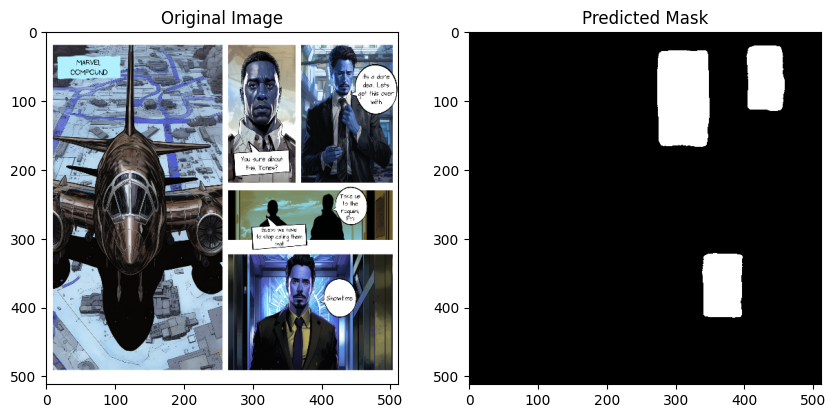

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(new_image[0])

plt.subplot(1, 2, 2)
plt.title("Predicted Mask")
plt.imshow(pred_mask[0, :, :, 0], cmap='gray')
plt.show()